In [1]:
import pandas as pd

df = pd.read_csv('../data/creditcard.csv')
print(df.shape)
print(df.head())

(284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V

In [3]:
print(f"Fraud rate: {df['Class'].mean()*100:.3f}%")

Fraud rate: 0.173%


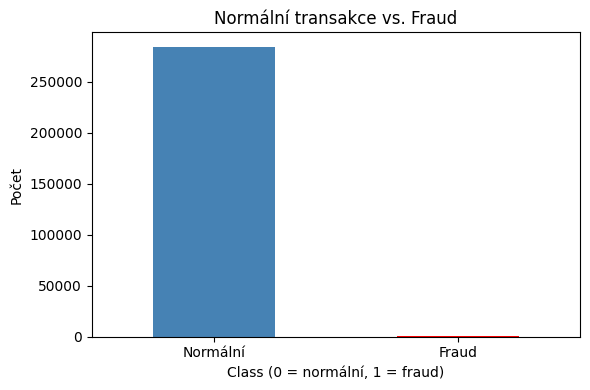

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
df['Class'].value_counts().plot(kind='bar', ax=ax, color=['steelblue', 'red'])
ax.set_title('Normální transakce vs. Fraud')
ax.set_xlabel('Class (0 = normální, 1 = fraud)')
ax.set_ylabel('Počet')
ax.set_xticklabels(['Normální', 'Fraud'], rotation=0)
plt.tight_layout()
plt.show()

C:\Users\START\AppData\Local\Temp\ipykernel_31520\710239662.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([normal['Amount'], fraud['Amount']], labels=['Normální', 'Fraud'])


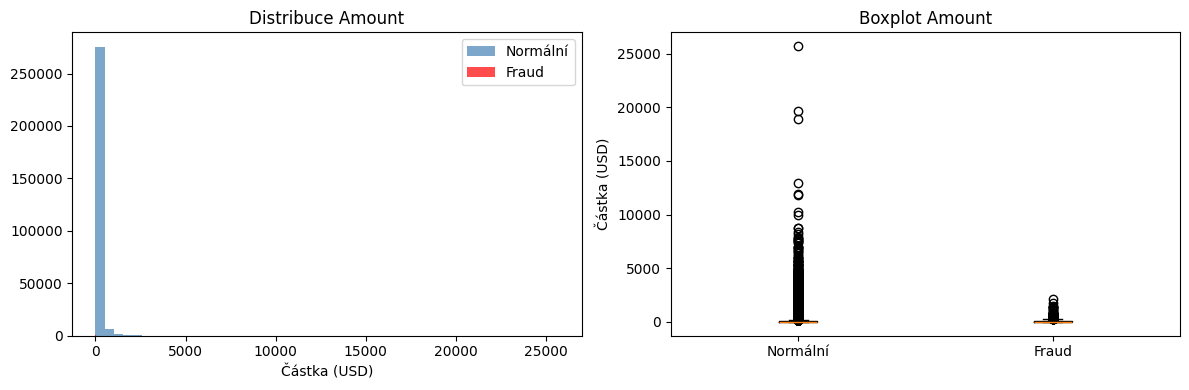

In [5]:
fraud = df[df['Class'] == 1]
normal = df[df['Class'] == 0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(normal['Amount'], bins=50, alpha=0.7, color='steelblue', label='Normální')
axes[0].hist(fraud['Amount'], bins=50, alpha=0.7, color='red', label='Fraud')
axes[0].set_title('Distribuce Amount')
axes[0].set_xlabel('Částka (USD)')
axes[0].legend()

axes[1].boxplot([normal['Amount'], fraud['Amount']], labels=['Normální', 'Fraud'])
axes[1].set_title('Boxplot Amount')
axes[1].set_ylabel('Částka (USD)')

plt.tight_layout()
plt.show()

In [6]:
print(df.groupby('Class')[['Amount', 'Time']].describe().round(2))

         Amount                                                          Time  \
          count    mean     std  min   25%    50%     75%       max     count   
Class                                                                           
0      284315.0   88.29  250.11  0.0  5.65  22.00   77.05  25691.16  284315.0   
1         492.0  122.21  256.68  0.0  1.00   9.25  105.89   2125.87     492.0   

                                                                        
           mean       std    min      25%      50%       75%       max  
Class                                                                   
0      94838.20  47484.02    0.0  54230.0  84711.0  139333.0  172792.0  
1      80746.81  47835.37  406.0  41241.5  75568.5  128483.0  170348.0  


In [1]:
import duckdb

con = duckdb.connect()
con.execute("CREATE TABLE transactions AS SELECT * FROM read_csv_auto('../data/creditcard.csv')")

result = con.execute("""
    SELECT 
        Class,
        COUNT(*) AS pocet,
        ROUND(AVG(Amount), 2) AS prumer_amount,
        ROUND(MAX(Amount), 2) AS max_amount
    FROM transactions
    GROUP BY Class
""").df()

print(result)

   Class   pocet  prumer_amount  max_amount
0      0  284315          88.29    25691.16
1      1     492         122.21     2125.87


In [2]:
result2 = con.execute("""
    SELECT
        Time,
        Amount,
        Class,
        ROUND((Amount - AVG(Amount) OVER()) / 
              NULLIF(STDDEV(Amount) OVER(), 0), 2) AS z_score
    FROM transactions
    ORDER BY Amount DESC
    LIMIT 20
""").df()

print(result2)

      Time    Amount  Class  z_score
0   166198  25691.16      0   102.36
1    48401  19656.53      0    78.24
2    95286  18910.00      0    75.25
3    42951  12910.93      0    51.27
4    46253  11898.09      0    47.22
5   119713  11789.84      0    46.78
6   172273  10199.44      0    40.42
7   145283  10000.00      0    39.63
8    55709   8790.26      0    34.79
9   152763   8787.00      0    34.78
10  144755   8360.00      0    33.07
11  145381   8182.70      0    32.36
12   30537   7879.42      0    31.15
13  150726   7862.39      0    31.08
14  128027   7766.60      0    30.70
15    1264   7712.43      0    30.48
16   47807   7636.30      0    30.18
17  133971   7583.32      0    29.97
18  141546   7541.70      0    29.80
19   32605   7429.15      0    29.35


In [3]:
result3 = con.execute("""
    SELECT
        CASE
            WHEN Amount < 10 THEN '< 10'
            WHEN Amount < 100 THEN '10–100'
            WHEN Amount < 1000 THEN '100–1000'
            ELSE '1000+'
        END AS pasmo,
        COUNT(*) AS celkem,
        SUM(Class) AS fraud_count,
        ROUND(100.0 * SUM(Class) / COUNT(*), 3) AS fraud_pct
    FROM transactions
    GROUP BY 1
    ORDER BY fraud_pct DESC
""").df()

print(result3)

      pasmo  celkem  fraud_count  fraud_pct
0     1000+    3069          9.0      0.293
1      < 10   97314        249.0      0.256
2  100–1000   54316        121.0      0.223
3    10–100  130108        113.0      0.087
